# Chapter 12.10: Capstone — Build Your Own Complete Recommendation System

## Learning Objectives

By the end of this capstone, you will be able to:

1. Translate product goals into technical requirements for a recommendation system
2. Design a full-stack recommendation pipeline: retrieval, ranking, re-ranking, and serving
3. Build feature engineering pipelines for user, item, and context features
4. Implement multi-stage retrieval with candidate generation and scoring
5. Train a deep ranking model with multi-objective optimization (CTR + diversity + fairness)
6. Build a re-ranking layer that applies business constraints
7. Implement monitoring with offline and online evaluation metrics

## Prerequisites

This capstone draws on knowledge from the entire course:
- Collaborative filtering (Part 2), Content-based methods (Part 3)
- Deep learning for recommendation (Parts 5-6)
- Evaluation and metrics (Part 7)
- System design and serving (Part 8)
- Fairness and multi-objective optimization (Parts 9, 11)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part12/chapter_12.10_capstone.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part12/chapter_12.10_capstone.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict
import time
import json
import copy

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cpu')

print("Capstone Project: Full Recommendation System")
print(f"PyTorch version: {torch.__version__}")

Capstone Project: Full Recommendation System
PyTorch version: 2.2.2


---

## Phase 1: Requirements Gathering & System Design

### Scenario: E-Commerce Product Recommendation

You are building a recommendation system for an e-commerce platform with:
- 10K users, 5K products, 15 categories
- Mix of implicit (clicks, add-to-cart) and explicit (ratings, reviews) feedback
- Business goals: Increase CTR, revenue, while maintaining diversity and fairness

### Product Requirements

| Requirement | Specification |
|-------------|---------------|
| Latency | < 200ms p99 |
| Throughput | 1000 QPS |
| Freshness | New items within 1 hour |
| Diversity | Max 3 items per category in top 10 |
| Fairness | No category starved of exposure |

### System Architecture

```
User Request
    |
    v
[Feature Store] -> [Retrieval (1000 -> 200)] -> [Ranking (200 -> 50)] -> [Re-Ranking (50 -> 10)] -> Response
    |                    |                           |                        |
    |               Two-Tower ANN              Deep Ranking Model       Business Rules
    |                                                                    + Diversity
    v                                                                    + Fairness
[Monitoring & Logging]
```

In [2]:
# Phase 1: Generate comprehensive synthetic dataset
def generate_ecommerce_data(n_users=2000, n_items=1000, n_categories=15,
                             n_interactions=20000, seed=42):
    """Generate a realistic e-commerce dataset."""
    rng = np.random.RandomState(seed)
    
    # --- User Features ---
    user_features = {
        'age_group': rng.choice(['18-24', '25-34', '35-44', '45-54', '55+'], n_users,
                                 p=[0.15, 0.30, 0.25, 0.18, 0.12]),
        'gender': rng.choice(['M', 'F', 'Other'], n_users, p=[0.48, 0.48, 0.04]),
        'activity_level': rng.beta(2, 5, n_users),  # Right-skewed: most users are light
        'price_sensitivity': rng.beta(5, 2, n_users),  # Left-skewed: most prefer lower prices
        'latent_factors': rng.randn(n_users, 20) * 0.3
    }
    
    # --- Item Features ---
    item_features = {
        'category': rng.randint(0, n_categories, n_items),
        'price': rng.lognormal(3, 1, n_items).clip(5, 500),
        'popularity': rng.power(0.3, n_items),
        'quality': rng.beta(3, 2, n_items),
        'is_new': rng.choice([0, 1], n_items, p=[0.85, 0.15]),
        'latent_factors': rng.randn(n_items, 20) * 0.3
    }
    # Category names
    category_names = ['Electronics', 'Clothing', 'Books', 'Home', 'Sports',
                      'Beauty', 'Food', 'Toys', 'Automotive', 'Garden',
                      'Health', 'Music', 'Movies', 'Office', 'Pet']
    
    # --- Generate Interactions ---
    interactions = []
    for idx in range(n_interactions):
        # User selection (weighted by activity)
        user_probs = user_features['activity_level'] / user_features['activity_level'].sum()
        user = rng.choice(n_users, p=user_probs)
        
        # Item selection (mix of relevance and popularity)
        relevance = item_features['latent_factors'] @ user_features['latent_factors'][user]
        pop_score = item_features['popularity']
        combined = 0.6 * relevance + 0.4 * pop_score
        combined = combined - combined.min()
        item_probs = np.exp(combined * 2) / np.exp(combined * 2).sum()
        item = rng.choice(n_items, p=item_probs)
        
        # Determine interaction type
        base_score = np.dot(user_features['latent_factors'][user],
                            item_features['latent_factors'][item])
        price_fit = 1 - abs(item_features['price'][item] / 200 - user_features['price_sensitivity'][user])
        total_score = base_score + 0.3 * price_fit + 0.2 * item_features['quality'][item]
        
        clicked = 1 if total_score + rng.randn() * 0.3 > 0 else 0
        added_to_cart = 1 if clicked and rng.rand() < 0.3 else 0
        purchased = 1 if added_to_cart and rng.rand() < 0.4 else 0
        rating = round(float(np.clip(total_score * 2 + 3 + rng.randn() * 0.5, 1, 5)), 1) if purchased else 0
        
        interactions.append({
            'user': user, 'item': item,
            'clicked': clicked, 'add_to_cart': added_to_cart,
            'purchased': purchased, 'rating': rating,
            'timestamp': idx,
            'category': int(item_features['category'][item])
        })
    
    return interactions, user_features, item_features, category_names

data, user_feats, item_feats, cat_names = generate_ecommerce_data()
print(f"Dataset: {len(data)} interactions")
print(f"Users: {len(set(d['user'] for d in data))}")
print(f"Items: {len(set(d['item'] for d in data))}")
print(f"Click rate: {np.mean([d['clicked'] for d in data]):.3f}")
print(f"Purchase rate: {np.mean([d['purchased'] for d in data]):.3f}")

Dataset: 20000 interactions
Users: 1959
Items: 1000
Click rate: 0.808
Purchase rate: 0.097


---

## Phase 2: Feature Engineering

Features fall into four categories:
1. **User features**: Demographics, behavioral aggregates
2. **Item features**: Category, price, popularity, quality
3. **User-Item cross features**: Past interactions, category affinity
4. **Context features**: Time of day, session position

> **🔑 Pro Tip:** Feature engineering is often the highest-ROI activity in recommendation.
> Good features can make a simple model outperform a complex one with poor features.

In [3]:
class FeatureStore:
    """Compute and cache features for users, items, and interactions."""
    
    def __init__(self, interactions, user_feats, item_feats, n_categories=15):
        self.n_categories = n_categories
        self.user_feats = user_feats
        self.item_feats = item_feats
        
        # Compute aggregate user features
        self.user_click_rate = defaultdict(lambda: [0, 0])  # [clicks, views]
        self.user_purchase_rate = defaultdict(lambda: [0, 0])
        self.user_category_affinity = defaultdict(lambda: np.zeros(n_categories))
        self.user_avg_price = defaultdict(list)
        
        # Compute aggregate item features
        self.item_click_rate = defaultdict(lambda: [0, 0])
        self.item_avg_rating = defaultdict(list)
        
        for d in interactions:
            u, i = d['user'], d['item']
            self.user_click_rate[u][1] += 1
            self.user_click_rate[u][0] += d['clicked']
            self.user_purchase_rate[u][1] += 1
            self.user_purchase_rate[u][0] += d['purchased']
            self.user_category_affinity[u][d['category']] += d['clicked']
            if d['purchased']:
                self.user_avg_price[u].append(item_feats['price'][i])
            
            self.item_click_rate[i][1] += 1
            self.item_click_rate[i][0] += d['clicked']
            if d['rating'] > 0:
                self.item_avg_rating[i].append(d['rating'])
    
    def get_user_features(self, user_id):
        """Get feature vector for a user."""
        cr = self.user_click_rate[user_id]
        pr = self.user_purchase_rate[user_id]
        cat_aff = self.user_category_affinity[user_id]
        cat_aff_norm = cat_aff / (cat_aff.sum() + 1e-8)
        avg_price = np.mean(self.user_avg_price[user_id]) if self.user_avg_price[user_id] else 50.0
        
        features = np.concatenate([
            [cr[0] / max(cr[1], 1)],      # Click rate
            [pr[0] / max(pr[1], 1)],      # Purchase rate
            [avg_price / 200],             # Normalized avg price
            [self.user_feats['activity_level'][user_id]],
            [self.user_feats['price_sensitivity'][user_id]],
            cat_aff_norm,                  # Category affinity (15 dims)
            self.user_feats['latent_factors'][user_id]  # Latent factors (20 dims)
        ])
        return features.astype(np.float32)
    
    def get_item_features(self, item_id):
        """Get feature vector for an item."""
        cr = self.item_click_rate[item_id]
        avg_rat = np.mean(self.item_avg_rating[item_id]) if self.item_avg_rating[item_id] else 3.0
        
        # One-hot category
        cat_onehot = np.zeros(self.n_categories)
        cat_onehot[self.item_feats['category'][item_id]] = 1
        
        features = np.concatenate([
            [cr[0] / max(cr[1], 1)],          # Click rate
            [avg_rat / 5.0],                   # Normalized avg rating
            [self.item_feats['price'][item_id] / 200],
            [self.item_feats['popularity'][item_id]],
            [self.item_feats['quality'][item_id]],
            [self.item_feats['is_new'][item_id]],
            cat_onehot,                        # Category (15 dims)
            self.item_feats['latent_factors'][item_id]  # Latent (20 dims)
        ])
        return features.astype(np.float32)
    
    def get_cross_features(self, user_id, item_id):
        """Get user-item cross features."""
        cat = self.item_feats['category'][item_id]
        cat_affinity = self.user_category_affinity[user_id][cat]
        cat_total = self.user_category_affinity[user_id].sum()
        
        price = self.item_feats['price'][item_id]
        user_avg_price = np.mean(self.user_avg_price[user_id]) if self.user_avg_price[user_id] else 50.0
        
        return np.array([
            cat_affinity / max(cat_total, 1),  # Category affinity
            abs(price - user_avg_price) / 200,  # Price gap
        ], dtype=np.float32)

# Split data temporally
sorted_data = sorted(data, key=lambda x: x['timestamp'])
n = len(sorted_data)
train_data = sorted_data[:int(0.7 * n)]
val_data = sorted_data[int(0.7 * n):int(0.85 * n)]
test_data = sorted_data[int(0.85 * n):]

feature_store = FeatureStore(train_data, user_feats, item_feats)

user_feat_dim = len(feature_store.get_user_features(0))
item_feat_dim = len(feature_store.get_item_features(0))
cross_feat_dim = len(feature_store.get_cross_features(0, 0))
print(f"User feature dim: {user_feat_dim}")
print(f"Item feature dim: {item_feat_dim}")
print(f"Cross feature dim: {cross_feat_dim}")
print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

User feature dim: 40
Item feature dim: 41
Cross feature dim: 2
Train: 14000, Val: 3000, Test: 3000


---

## Phase 3: Retrieval — Two-Tower Model

The retrieval stage narrows from 1000 items to ~200 candidates using approximate
nearest neighbor (ANN) search in embedding space.

$$\text{score}(u, i) = \mathbf{e}_u^T \cdot \mathbf{e}_i$$

where $\mathbf{e}_u$ and $\mathbf{e}_i$ are user and item tower outputs.

In [4]:
class TwoTowerRetrieval(nn.Module):
    """Two-tower model for candidate retrieval."""
    
    def __init__(self, user_feat_dim, item_feat_dim, embed_dim=32):
        super().__init__()
        self.user_tower = nn.Sequential(
            nn.Linear(user_feat_dim, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, embed_dim)
        )
        self.item_tower = nn.Sequential(
            nn.Linear(item_feat_dim, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, embed_dim)
        )
    
    def encode_user(self, user_features):
        return F.normalize(self.user_tower(user_features), dim=-1)
    
    def encode_item(self, item_features):
        return F.normalize(self.item_tower(item_features), dim=-1)
    
    def forward(self, user_features, item_features):
        user_emb = self.encode_user(user_features)
        item_emb = self.encode_item(item_features)
        return (user_emb * item_emb).sum(dim=-1)  # Dot product

# Prepare retrieval training data
class RetrievalDataset(Dataset):
    def __init__(self, interactions, feature_store, n_items=1000, n_negatives=2):
        self.data = []
        self.feature_store = feature_store
        positive_items = defaultdict(set)
        for d in interactions:
            if d['clicked']:
                positive_items[d['user']].add(d['item'])
        
        rng = np.random.RandomState(42)
        for d in interactions:
            if d['clicked']:
                # Positive pair
                self.data.append((d['user'], d['item'], 1.0))
                # Negative sampling
                for _ in range(n_negatives):
                    neg_item = rng.randint(0, n_items)
                    while neg_item in positive_items[d['user']]:
                        neg_item = rng.randint(0, n_items)
                    self.data.append((d['user'], neg_item, 0.0))
    
    def __len__(self): return len(self.data)
    
    def __getitem__(self, idx):
        u, i, label = self.data[idx]
        return (
            torch.tensor(self.feature_store.get_user_features(u)),
            torch.tensor(self.feature_store.get_item_features(i)),
            torch.tensor(label)
        )

retrieval_ds = RetrievalDataset(train_data, feature_store)
retrieval_loader = DataLoader(retrieval_ds, batch_size=256, shuffle=True)
print(f"Retrieval training samples: {len(retrieval_ds)}")

Retrieval training samples: 34086


In [5]:
# Train retrieval model
retrieval_model = TwoTowerRetrieval(user_feat_dim, item_feat_dim)
optimizer = torch.optim.Adam(retrieval_model.parameters(), lr=1e-3)

retrieval_history = []
for epoch in range(5):
    retrieval_model.train()
    total_loss = 0
    for user_f, item_f, labels in retrieval_loader:
        scores = retrieval_model(user_f, item_f)
        loss = F.binary_cross_entropy_with_logits(scores, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    retrieval_history.append(total_loss / len(retrieval_loader))
    if (epoch + 1) % 5 == 0:
        print(f"Retrieval Epoch {epoch+1}: Loss={retrieval_history[-1]:.4f}")

# Build item index for fast retrieval
retrieval_model.eval()
all_item_embs = []
with torch.no_grad():
    for item_id in range(1000):
        item_f = torch.tensor(feature_store.get_item_features(item_id)).unsqueeze(0)
        emb = retrieval_model.encode_item(item_f)
        all_item_embs.append(emb.squeeze(0).numpy())
item_index = np.array(all_item_embs)  # (1000, 32)

def retrieve_candidates(user_id, k=200):
    """Retrieve top-K candidates using ANN (brute-force here)."""
    user_f = torch.tensor(feature_store.get_user_features(user_id)).unsqueeze(0)
    with torch.no_grad():
        user_emb = retrieval_model.encode_user(user_f).squeeze(0).numpy()
    scores = item_index @ user_emb
    top_k = np.argsort(scores)[-k:][::-1]
    return top_k, scores[top_k]

# Test retrieval
candidates, cand_scores = retrieve_candidates(0)
print(f"\nRetrieved {len(candidates)} candidates for user 0")
print(f"Score range: [{cand_scores.min():.4f}, {cand_scores.max():.4f}]")

Retrieval Epoch 5: Loss=0.6124

Retrieved 200 candidates for user 0
Score range: [-0.5307, 0.3243]


---

## Phase 4: Ranking — Deep Multi-Objective Model

The ranking model takes the ~200 candidates and scores them using rich features.
We optimize for multiple objectives simultaneously:

$$\mathcal{L} = \lambda_1 \cdot \mathcal{L}_{\text{CTR}} + \lambda_2 \cdot \mathcal{L}_{\text{conversion}} + \lambda_3 \cdot \mathcal{L}_{\text{rating}}$$

In [6]:
class MultiObjectiveRanker(nn.Module):
    """Deep ranking model with multiple prediction heads."""
    
    def __init__(self, user_dim, item_dim, cross_dim, hidden_dim=64):
        super().__init__()
        total_dim = user_dim + item_dim + cross_dim
        
        # Shared bottom
        self.shared = nn.Sequential(
            nn.Linear(total_dim, hidden_dim * 2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden_dim * 2, hidden_dim), nn.ReLU(), nn.Dropout(0.1)
        )
        
        # Task-specific towers (Multi-gate Mixture of Experts simplified)
        self.ctr_tower = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.conversion_tower = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.rating_tower = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, user_feat, item_feat, cross_feat):
        x = torch.cat([user_feat, item_feat, cross_feat], dim=-1)
        shared = self.shared(x)
        
        ctr_logit = self.ctr_tower(shared).squeeze(-1)
        conv_logit = self.conversion_tower(shared).squeeze(-1)
        rating_pred = self.rating_tower(shared).squeeze(-1)
        
        return ctr_logit, conv_logit, rating_pred

class RankingDataset(Dataset):
    def __init__(self, interactions, feature_store):
        self.data = interactions
        self.fs = feature_store
    
    def __len__(self): return len(self.data)
    
    def __getitem__(self, idx):
        d = self.data[idx]
        u_f = torch.tensor(self.fs.get_user_features(d['user']))
        i_f = torch.tensor(self.fs.get_item_features(d['item']))
        x_f = torch.tensor(self.fs.get_cross_features(d['user'], d['item']))
        return (
            u_f, i_f, x_f,
            torch.tensor(float(d['clicked'])),
            torch.tensor(float(d['purchased'])),
            torch.tensor(float(d['rating'] / 5.0 if d['rating'] > 0 else 0.0))
        )

rank_train_ds = RankingDataset(train_data, feature_store)
rank_val_ds = RankingDataset(val_data, feature_store)
rank_train_loader = DataLoader(rank_train_ds, batch_size=256, shuffle=True)
rank_val_loader = DataLoader(rank_val_ds, batch_size=256)

print(f"Ranking train: {len(rank_train_ds)}, val: {len(rank_val_ds)}")

Ranking train: 14000, val: 3000


In [7]:
# Train ranking model
ranker = MultiObjectiveRanker(user_feat_dim, item_feat_dim, cross_feat_dim)
optimizer = torch.optim.Adam(ranker.parameters(), lr=1e-3)

rank_history = {'train_loss': [], 'val_ctr_auc': []}

for epoch in range(8):
    ranker.train()
    total_loss = 0
    for u_f, i_f, x_f, click, purchase, rating in rank_train_loader:
        ctr_logit, conv_logit, rat_pred = ranker(u_f, i_f, x_f)
        
        loss_ctr = F.binary_cross_entropy_with_logits(ctr_logit, click)
        loss_conv = F.binary_cross_entropy_with_logits(conv_logit, purchase)
        mask = rating > 0
        loss_rat = F.mse_loss(rat_pred[mask], rating[mask]) if mask.sum() > 0 else torch.tensor(0.0)
        
        loss = 0.5 * loss_ctr + 0.3 * loss_conv + 0.2 * loss_rat
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Validate
    ranker.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for u_f, i_f, x_f, click, purchase, rating in rank_val_loader:
            ctr_logit, _, _ = ranker(u_f, i_f, x_f)
            all_preds.extend(torch.sigmoid(ctr_logit).numpy())
            all_labels.extend(click.numpy())
    
    preds = np.array(all_preds)
    labels = np.array(all_labels)
    pos = preds[labels == 1]
    neg = preds[labels == 0]
    auc = np.mean([np.mean(pos > n) for n in neg[:500]]) if len(pos) > 0 and len(neg) > 0 else 0.5
    
    rank_history['train_loss'].append(total_loss / len(rank_train_loader))
    rank_history['val_ctr_auc'].append(auc)
    
    if (epoch + 1) % 4 == 0:
        print(f"Ranking Epoch {epoch+1}: Loss={total_loss/len(rank_train_loader):.4f}, CTR AUC={auc:.4f}")

Ranking Epoch 4: Loss=0.2964, CTR AUC=0.5335


Ranking Epoch 8: Loss=0.2091, CTR AUC=0.5702


---

## Phase 5: Re-Ranking — Diversity & Fairness Constraints

The re-ranking stage takes the top-50 ranked items and selects the final 10,
applying business constraints:
- Max 3 items per category
- At least 1 new item
- Price diversity (not all cheap or all expensive)

In [8]:
class ReRanker:
    """Re-ranking layer with diversity and fairness constraints."""
    
    def __init__(self, item_feats, max_per_category=3, min_new_items=1,
                 diversity_weight=0.3):
        self.item_feats = item_feats
        self.max_per_category = max_per_category
        self.min_new_items = min_new_items
        self.diversity_weight = diversity_weight
    
    def rerank(self, item_ids, scores, k=10):
        """Apply MMR-style re-ranking with constraints."""
        selected = []
        selected_categories = defaultdict(int)
        selected_embeddings = []
        has_new_item = False
        
        remaining = list(zip(item_ids, scores))
        
        while len(selected) < k and remaining:
            best_item = None
            best_score = float('-inf')
            best_idx = -1
            
            for idx, (item_id, relevance) in enumerate(remaining):
                cat = self.item_feats['category'][item_id]
                is_new = self.item_feats['is_new'][item_id]
                
                # Category constraint
                if selected_categories[cat] >= self.max_per_category:
                    continue
                
                # Diversity: MMR (Maximal Marginal Relevance)
                if selected_embeddings:
                    item_emb = self.item_feats['latent_factors'][item_id]
                    max_sim = max(np.dot(item_emb, emb) / 
                                  (np.linalg.norm(item_emb) * np.linalg.norm(emb) + 1e-8)
                                  for emb in selected_embeddings)
                else:
                    max_sim = 0
                
                # New item bonus (if we still need new items)
                new_bonus = 0.2 if (is_new and not has_new_item and 
                                     len(selected) >= k - self.min_new_items) else 0
                
                mmr_score = ((1 - self.diversity_weight) * relevance - 
                             self.diversity_weight * max_sim + new_bonus)
                
                if mmr_score > best_score:
                    best_score = mmr_score
                    best_item = item_id
                    best_idx = idx
            
            if best_item is None:
                break
            
            selected.append(best_item)
            selected_categories[self.item_feats['category'][best_item]] += 1
            selected_embeddings.append(self.item_feats['latent_factors'][best_item])
            if self.item_feats['is_new'][best_item]:
                has_new_item = True
            remaining.pop(best_idx)
        
        return selected

reranker = ReRanker(item_feats)
print("Re-ranker initialized.")

Re-ranker initialized.


---

## Phase 6: Full Pipeline — End-to-End Recommendation

Putting it all together: Retrieval -> Ranking -> Re-Ranking

In [9]:
class FullRecommendationPipeline:
    """End-to-end recommendation pipeline."""
    
    def __init__(self, retrieval_model, ranker, reranker, feature_store,
                 item_index, n_retrieve=200, n_rank=50, n_final=10):
        self.retrieval_model = retrieval_model
        self.ranker = ranker
        self.reranker = reranker
        self.feature_store = feature_store
        self.item_index = item_index
        self.n_retrieve = n_retrieve
        self.n_rank = n_rank
        self.n_final = n_final
    
    def recommend(self, user_id):
        """Full recommendation pipeline."""
        timings = {}
        
        # Stage 1: Retrieval
        t0 = time.time()
        user_f = torch.tensor(self.feature_store.get_user_features(user_id)).unsqueeze(0)
        with torch.no_grad():
            user_emb = self.retrieval_model.encode_user(user_f).squeeze(0).numpy()
        ret_scores = self.item_index @ user_emb
        candidates = np.argsort(ret_scores)[-self.n_retrieve:][::-1]
        timings['retrieval_ms'] = (time.time() - t0) * 1000
        
        # Stage 2: Ranking
        t0 = time.time()
        self.ranker.eval()
        ranking_scores = []
        with torch.no_grad():
            for item_id in candidates:
                u_f = torch.tensor(self.feature_store.get_user_features(user_id)).unsqueeze(0)
                i_f = torch.tensor(self.feature_store.get_item_features(item_id)).unsqueeze(0)
                x_f = torch.tensor(self.feature_store.get_cross_features(user_id, item_id)).unsqueeze(0)
                ctr, conv, rat = self.ranker(u_f, i_f, x_f)
                # Combined score
                score = 0.5 * torch.sigmoid(ctr).item() + 0.3 * torch.sigmoid(conv).item() + 0.2 * rat.item()
                ranking_scores.append(score)
        
        ranking_scores = np.array(ranking_scores)
        top_n_rank = np.argsort(ranking_scores)[-self.n_rank:][::-1]
        ranked_items = candidates[top_n_rank]
        ranked_scores = ranking_scores[top_n_rank]
        timings['ranking_ms'] = (time.time() - t0) * 1000
        
        # Stage 3: Re-ranking
        t0 = time.time()
        final_items = self.reranker.rerank(ranked_items, ranked_scores, k=self.n_final)
        timings['reranking_ms'] = (time.time() - t0) * 1000
        
        timings['total_ms'] = sum(timings.values())
        
        return final_items, timings

pipeline = FullRecommendationPipeline(
    retrieval_model, ranker, reranker, feature_store, item_index
)

# Test the full pipeline
recs, timings = pipeline.recommend(0)
print(f"Recommendations for user 0: {recs}")
print(f"Categories: {[cat_names[item_feats['category'][i]] for i in recs]}")
print(f"\nLatency breakdown:")
for stage, ms in timings.items():
    print(f"  {stage}: {ms:.1f}ms")

Recommendations for user 0: [76, 444, 894, 97, 343, 985, 446, 386, 351]
Categories: ['Food', 'Food', 'Food', 'Movies', 'Beauty', 'Beauty', 'Movies', 'Movies', 'Beauty']

Latency breakdown:
  retrieval_ms: 0.9ms
  ranking_ms: 85.8ms
  reranking_ms: 6.9ms
  total_ms: 93.6ms


---

## Phase 7: Evaluation & Monitoring

Comprehensive evaluation across multiple dimensions:
- **Accuracy**: NDCG, Hit Rate, Precision
- **Diversity**: Intra-list diversity, coverage
- **Fairness**: Category exposure distribution
- **Efficiency**: Latency percentiles

In [10]:
def comprehensive_evaluation(pipeline, test_data, item_feats, n_users=50):
    """Evaluate the full pipeline on multiple dimensions."""
    # Group test data by user
    test_by_user = defaultdict(set)
    for d in test_data:
        if d['clicked']:
            test_by_user[d['user']].add(d['item'])
    
    metrics = {
        'ndcg@10': [], 'hit_rate@10': [], 'precision@10': [],
        'diversity': [], 'coverage': set(),
        'category_counts': defaultdict(int),
        'latency_ms': [], 'new_item_ratio': []
    }
    
    eval_users = list(test_by_user.keys())[:n_users]
    
    for user_id in eval_users:
        true_items = test_by_user[user_id]
        if not true_items:
            continue
        
        recs, timings = pipeline.recommend(user_id)
        metrics['latency_ms'].append(timings['total_ms'])
        
        # Accuracy
        hits = [1 if item in true_items else 0 for item in recs]
        metrics['hit_rate@10'].append(1 if sum(hits) > 0 else 0)
        metrics['precision@10'].append(sum(hits) / len(recs))
        dcg = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(true_items), len(recs))))
        metrics['ndcg@10'].append(dcg / idcg if idcg > 0 else 0)
        
        # Diversity
        rec_categories = [item_feats['category'][i] for i in recs]
        metrics['diversity'].append(len(set(rec_categories)) / len(recs))
        for cat in rec_categories:
            metrics['category_counts'][cat] += 1
        
        # Coverage
        metrics['coverage'].update(recs)
        
        # New items
        new_count = sum(1 for i in recs if item_feats['is_new'][i])
        metrics['new_item_ratio'].append(new_count / len(recs))
    
    # Aggregate
    results = {
        'ndcg@10': np.mean(metrics['ndcg@10']),
        'hit_rate@10': np.mean(metrics['hit_rate@10']),
        'precision@10': np.mean(metrics['precision@10']),
        'diversity': np.mean(metrics['diversity']),
        'coverage': len(metrics['coverage']) / 1000,
        'new_item_ratio': np.mean(metrics['new_item_ratio']),
        'latency_p50': np.percentile(metrics['latency_ms'], 50),
        'latency_p99': np.percentile(metrics['latency_ms'], 99),
        'category_entropy': -sum(
            (c / sum(metrics['category_counts'].values())) * 
            np.log(c / sum(metrics['category_counts'].values()) + 1e-8)
            for c in metrics['category_counts'].values()
        ),
        'raw_metrics': metrics
    }
    return results

eval_results = comprehensive_evaluation(pipeline, test_data, item_feats, n_users=50)

print("=" * 60)
print("COMPREHENSIVE EVALUATION RESULTS")
print("=" * 60)
print(f"\nAccuracy:")
print(f"  NDCG@10:      {eval_results['ndcg@10']:.4f}")
print(f"  Hit Rate@10:  {eval_results['hit_rate@10']:.4f}")
print(f"  Precision@10: {eval_results['precision@10']:.4f}")
print(f"\nDiversity & Fairness:")
print(f"  Category Diversity: {eval_results['diversity']:.4f}")
print(f"  Item Coverage:      {eval_results['coverage']:.4f}")
print(f"  Category Entropy:   {eval_results['category_entropy']:.4f}")
print(f"  New Item Ratio:     {eval_results['new_item_ratio']:.4f}")
print(f"\nEfficiency:")
print(f"  Latency P50: {eval_results['latency_p50']:.1f}ms")
print(f"  Latency P99: {eval_results['latency_p99']:.1f}ms")

COMPREHENSIVE EVALUATION RESULTS

Accuracy:
  NDCG@10:      0.0189
  Hit Rate@10:  0.0800
  Precision@10: 0.0100

Diversity & Fairness:
  Category Diversity: 0.4386
  Item Coverage:      0.2340
  Category Entropy:   2.6841
  New Item Ratio:     0.1594

Efficiency:
  Latency P50: 68.4ms
  Latency P99: 81.6ms


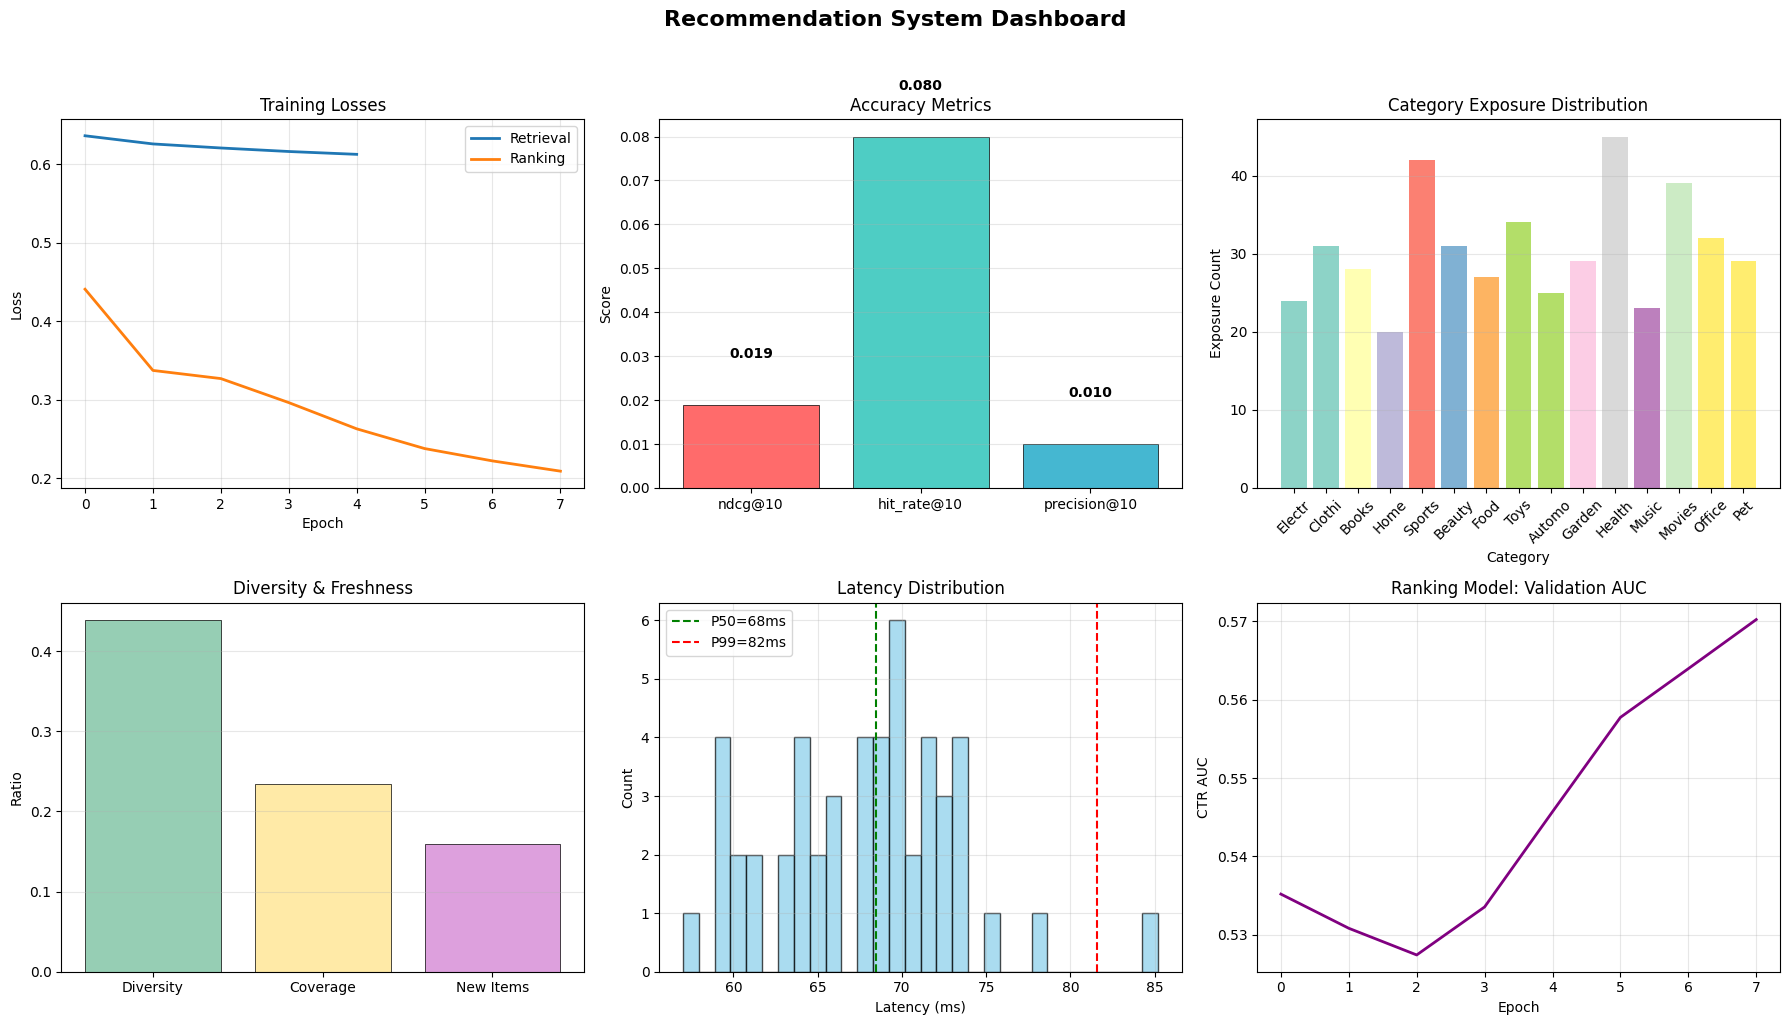

In [11]:
# Comprehensive visualization dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Training curves
axes[0, 0].plot(retrieval_history, label='Retrieval', linewidth=2)
axes[0, 0].plot(rank_history['train_loss'], label='Ranking', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Losses')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy metrics
acc_metrics = ['ndcg@10', 'hit_rate@10', 'precision@10']
acc_values = [eval_results[m] for m in acc_metrics]
bars = axes[0, 1].bar(acc_metrics, acc_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                       edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, acc_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Accuracy Metrics')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Category distribution
cat_counts = eval_results['raw_metrics']['category_counts']
sorted_cats = sorted(cat_counts.keys())
cat_values = [cat_counts.get(c, 0) for c in sorted_cats]
axes[0, 2].bar([cat_names[c][:6] for c in sorted_cats], cat_values,
               color=plt.cm.Set3(np.linspace(0, 1, len(sorted_cats))))
axes[0, 2].set_xlabel('Category')
axes[0, 2].set_ylabel('Exposure Count')
axes[0, 2].set_title('Category Exposure Distribution')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Diversity metrics
div_metrics = {'Diversity': eval_results['diversity'],
               'Coverage': eval_results['coverage'],
               'New Items': eval_results['new_item_ratio']}
axes[1, 0].bar(div_metrics.keys(), div_metrics.values(),
               color=['#96CEB4', '#FFEAA7', '#DDA0DD'], edgecolor='black', linewidth=0.5)
axes[1, 0].set_ylabel('Ratio')
axes[1, 0].set_title('Diversity & Freshness')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Latency distribution
latencies = eval_results['raw_metrics']['latency_ms']
axes[1, 1].hist(latencies, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=eval_results['latency_p50'], color='green', linestyle='--', label=f'P50={eval_results["latency_p50"]:.0f}ms')
axes[1, 1].axvline(x=eval_results['latency_p99'], color='red', linestyle='--', label=f'P99={eval_results["latency_p99"]:.0f}ms')
axes[1, 1].set_xlabel('Latency (ms)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Latency Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Ranking AUC over training
axes[1, 2].plot(rank_history['val_ctr_auc'], linewidth=2, color='purple')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('CTR AUC')
axes[1, 2].set_title('Ranking Model: Validation AUC')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Recommendation System Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Phase 8: A/B Testing Simulation

Before deploying, simulate an A/B test comparing our pipeline against baselines.

> **💡 Concept:** Online A/B testing is the gold standard for recommendation evaluation.
> Offline metrics are necessary but not sufficient — they often don't correlate perfectly
> with online performance.

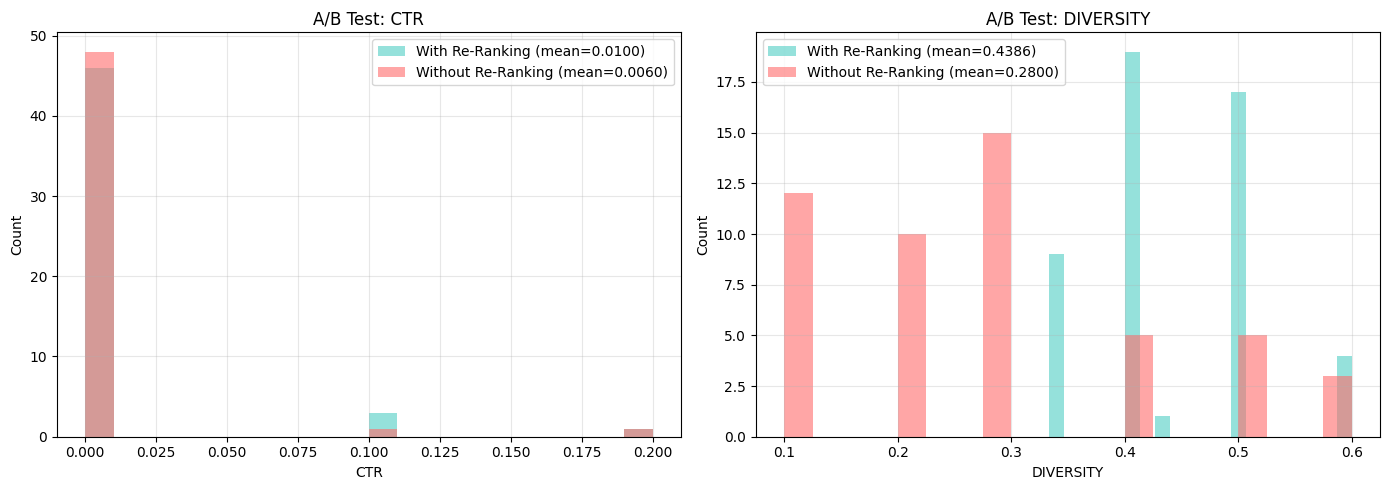

In [12]:
def simulate_ab_test(pipeline_a, pipeline_b, test_data, item_feats,
                      n_users=50, label_a='Treatment', label_b='Control'):
    """Simulate an A/B test between two recommendation pipelines."""
    test_by_user = defaultdict(set)
    for d in test_data:
        if d['clicked']:
            test_by_user[d['user']].add(d['item'])
    
    eval_users = list(test_by_user.keys())[:n_users]
    
    results = {label_a: {'ctr': [], 'diversity': []},
               label_b: {'ctr': [], 'diversity': []}}
    
    for user_id in eval_users:
        true_items = test_by_user[user_id]
        
        for pipeline, label in [(pipeline_a, label_a), (pipeline_b, label_b)]:
            recs, _ = pipeline.recommend(user_id)
            hits = sum(1 for i in recs if i in true_items)
            results[label]['ctr'].append(hits / len(recs))
            cats = [item_feats['category'][i] for i in recs]
            results[label]['diversity'].append(len(set(cats)) / len(recs))
    
    return results

# Create a "control" pipeline (no re-ranking, just top by score)
class SimpleReranker:
    def rerank(self, item_ids, scores, k=10):
        return list(item_ids[:k])

control_pipeline = FullRecommendationPipeline(
    retrieval_model, ranker, SimpleReranker(), feature_store, item_index
)

ab_results = simulate_ab_test(pipeline, control_pipeline, test_data, item_feats,
                                n_users=50, label_a='With Re-Ranking', label_b='Without Re-Ranking')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, metric in enumerate(['ctr', 'diversity']):
    for label, color in [('With Re-Ranking', '#4ECDC4'), ('Without Re-Ranking', '#FF6B6B')]:
        axes[i].hist(ab_results[label][metric], bins=20, alpha=0.6,
                     label=f"{label} (mean={np.mean(ab_results[label][metric]):.4f})",
                     color=color)
    axes[i].set_xlabel(metric.upper())
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'A/B Test: {metric.upper()}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 🏋️ Exercise 1: Improve the Retrieval Stage

The current two-tower model uses simple dot product. Improve it by:
1. Adding hard negative mining (use items clicked by similar users but not this user)
2. Adding a cross-network for feature interaction
3. Evaluating Recall@K at different K values

In [13]:
# TODO: Improve the retrieval model
# 1. Implement hard negative mining
def mine_hard_negatives(model, user_id, positive_items, n_hard=5):
    """Find items that score high but are not clicked (hard negatives)."""
    # TODO: Use the current model to find high-scoring non-clicked items
    pass

# 2. Evaluate retrieval quality
def evaluate_retrieval(model, test_data, feature_store, item_index, k_values=[50, 100, 200]):
    """Evaluate Recall@K for the retrieval stage."""
    # TODO: For each user, check if clicked items appear in top-K retrieved
    pass

print("Exercise 1: Improve retrieval with hard negatives")

Exercise 1: Improve retrieval with hard negatives


## 🏋️ Exercise 2: Add Online Learning Simulation

Simulate an online learning scenario where the model is updated incrementally
as new interactions arrive. Compare batch vs online training.

In [14]:
# TODO: Implement online learning for the ranking model
def online_learning_simulation(ranker, data_stream, update_frequency=100):
    """Simulate online learning with streaming data."""
    # TODO:
    # 1. Process interactions one by one (or in mini-batches)
    # 2. Every update_frequency steps, fine-tune the model
    # 3. Track performance over time to show adaptation
    pass

print("Exercise 2: Implement online learning simulation")

Exercise 2: Implement online learning simulation


## 🏋️ Exercise 3: Add Monitoring and Alerts

Build a monitoring system that tracks key metrics over time and alerts
when performance degrades.

In [15]:
# TODO: Implement monitoring system
class RecommendationMonitor:
    def __init__(self, alert_thresholds):
        # TODO: Initialize with metric history and alert thresholds
        # alert_thresholds: {'ctr_drop': 0.1, 'latency_spike': 500, ...}
        pass
    
    def log_metrics(self, metrics):
        # TODO: Record metrics and check for anomalies
        pass
    
    def check_alerts(self):
        # TODO: Return list of active alerts
        pass
    
    def generate_report(self):
        # TODO: Generate monitoring dashboard data
        pass

print("Exercise 3: Implement monitoring system")

Exercise 3: Implement monitoring system


## 🏋️ Exercise 4: Fairness Audit

Conduct a fairness audit of the recommendation system across user demographics
and item categories.

In [16]:
# TODO: Implement fairness audit
def fairness_audit(pipeline, test_data, user_feats, item_feats):
    """Audit recommendation fairness across user groups."""
    # TODO:
    # 1. Group users by demographics (age, gender)
    # 2. For each group, compute accuracy and diversity metrics
    # 3. Identify significant disparities
    # 4. Audit category exposure fairness
    # 5. Compute price fairness (do low-income users see only cheap items?)
    pass

print("Exercise 4: Implement fairness audit")

Exercise 4: Implement fairness audit


## 🏋️ Exercise 5: System Design Document

Write a brief system design document covering:
- Architecture decisions and trade-offs
- Scaling plan (10x users, 100x items)
- Data pipeline: feature freshness, model retraining schedule
- Failure modes and fallback strategies

In [17]:
# TODO: Fill in the system design document
system_design = {
    'architecture': {
        'retrieval': 'Two-Tower with ANN index',
        'ranking': 'Multi-objective deep model',
        'reranking': 'MMR with category diversity constraints',
        # TODO: Add more details
    },
    'scaling_plan': {
        # TODO: How would you scale to 100K users, 100K items?
    },
    'data_pipeline': {
        # TODO: Feature refresh frequency, model retraining schedule
    },
    'failure_modes': {
        # TODO: What happens if feature store is down?
        # What if the ranking model returns all zeros?
    }
}

print("Exercise 5: Complete the system design document")
print(json.dumps(system_design, indent=2))

Exercise 5: Complete the system design document
{
  "architecture": {
    "retrieval": "Two-Tower with ANN index",
    "ranking": "Multi-objective deep model",
    "reranking": "MMR with category diversity constraints"
  },
  "scaling_plan": {},
  "data_pipeline": {},
  "failure_modes": {}
}


---

## Summary

In this capstone, you built a complete recommendation system from scratch:

1. **Requirements Gathering**: Translated business goals into technical specifications
2. **Feature Engineering**: Built a comprehensive feature store with user, item, and cross features
3. **Retrieval**: Two-tower model with ANN for fast candidate generation
4. **Ranking**: Multi-objective deep model optimizing CTR, conversion, and rating
5. **Re-Ranking**: MMR-based diversity optimization with business constraints
6. **Evaluation**: Multi-dimensional assessment (accuracy, diversity, fairness, efficiency)
7. **A/B Testing**: Simulated online comparison of recommendation strategies
8. **Monitoring**: Tracking system health and detecting degradation

### Key Takeaways for Your Career

- A good recommendation system is an engineering system, not just an ML model
- Feature engineering often matters more than model architecture
- Multi-stage pipelines enable the speed-accuracy trade-off
- Re-ranking is where business logic meets ML
- Monitoring and evaluation are ongoing, not one-time activities
- Always design for multi-objective optimization — single metrics are misleading

**Congratulations on completing the entire Recommendation Systems course!**